# Entrega II - Python para ciência de dados

Por: João Rodrigo Dias Costa

## Setup

In [32]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/vendas_brasil_1.csv")

Investigação inicial:

In [33]:
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


## Entregável 1 NumPy

### A. Criando arrays

In [34]:
preco_unitario = df['preco_unitario'].to_numpy()
custo_unitario = df['custo_unitario'].to_numpy()
quantidade = df['quantidade'].to_numpy()
desconto_por_cento = df['desconto_pct'].to_numpy()
receita_total = df['receita_total'].to_numpy()
frete = df['frete'].to_numpy()

### B. Cálculo com operações vetorizadas

In [35]:
valor_bruto_da_venda = quantidade * preco_unitario
valor_do_desconto = valor_bruto_da_venda * (desconto_por_cento/100)
custo_total = quantidade * custo_unitario
lucro_estimado = valor_bruto_da_venda - custo_total

### C. Máscaras booleanas

In [36]:
# vendas com receita acima da média

result1 = receita_total[receita_total > receita_total.mean()].size
print(str(result1) + " vendas com receita acima da média.")


# vendas com prejuízo

result2 = custo_total[custo_total > receita_total].size
print(str(result2) + " vendas com prejuízo.")

# vendas com desconto alto
# valor arbitrário: 25%

result3 = desconto_por_cento[desconto_por_cento > 25].size
print(str(result3) + " vendas com desconto alto.")


9236 vendas com receita acima da média.
2168 vendas com prejuízo.
2304 vendas com desconto alto.


### D. Agregações

In [37]:
receita_media = receita_total.mean()
print("receita média: " + str(receita_media))

maior_receita = receita_total.max()
print("maior receita: " + str(maior_receita))

menor_receita = receita_total.min()
print("menor receita: " + str(menor_receita))

lucro_medio = lucro_estimado.mean()
print("lucro médio: " + str(lucro_medio))

# é o mesmo caso do que foi solicitado na seção de máscaras booleanas
quant_vendas_prejuizo = result2
print("quantidade de vendas com prejuízo: " + str(quant_vendas_prejuizo))


receita média: 1891.6881729005502
maior receita: 58430.28
menor receita: 3.7
lucro médio: 522.4008070819044
quantidade de vendas com prejuízo: 2168


As vendas aparentam estar satisfatórias (~522 de lucro médio é um indicativo de que as vendas com prejuízo/desconto incentivam o consumidor e, ao mesmo tempo, não afetam tanto a lucratividade do comércio). Para analisar os demais indicadores, como 1891 de receita média, necessita-se saber o tamanho da empresa para realizar uma comparação honesta.

## Entregável 2 Pandas

### A. Primeiro olhar no dataset

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [39]:
df.describe

<bound method NDFrame.describe of        data_venda  mes          cidade  canal_venda    categoria  \
0      2022-04-13    4  Rio de Janeiro   App Mobile  Eletrônicos   
1      2023-03-12    3          Manaus     Site Web    Vestuário   
2      2022-09-28    9         Goiânia   App Mobile    Vestuário   
3      2022-04-17    4       Fortaleza     Site Web    Vestuário   
4      2022-03-13    3  Belo Horizonte   App Mobile     Esportes   
...           ...  ...             ...          ...          ...   
37612  2023-12-31    3    Porto Alegre   App Mobile  Alimentação   
37613  2023-12-31    9        Salvador     Site Web  Alimentação   
37614  2023-12-31    2        Salvador  Loja Física  Alimentação   
37615  2023-12-31   11       São Paulo     Site Web     Esportes   
37616  2023-12-31    4       Fortaleza   Televendas  Eletrônicos   

               produto       vendedor fidelidade_cliente  preco_unitario  \
0             Notebook    Bruno Souza           Diamante          739.39 

In [40]:
df.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

In [41]:
df.loc[0]

data_venda                2022-04-13
mes                                4
cidade                Rio de Janeiro
canal_venda               App Mobile
categoria                Eletrônicos
produto                     Notebook
vendedor                 Bruno Souza
fidelidade_cliente          Diamante
preco_unitario                739.39
custo_unitario                561.75
margem_pct                     22.31
quantidade                        10
desconto_pct                     5.2
receita_total                6933.48
frete                           8.68
avaliacao_cliente               4.92
prazo_entrega_dias               5.0
devolucao                      False
entrega_no_prazo                True
alta_temporada                 False
flag_outlier_preco             False
Name: 0, dtype: object

**1. Quantas linhas e colunas existem?**
37617 linhas e 21 colunas, pelo _df.describe_.

**2. Existem dados faltantes?**
Sim, pelo _df.isna().sum()_ observam-se dados faltantes em _canal_venda_, _vendedor_, _margem_pct_, e mais outras colunas.

**3. Quais colunas parecem numéricas?**
mes, preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente, prazo_entrega_dias

**4. Quais colunas parecem categóricas?**
cidade, canal_venda, categoria, produto, vendedo, fidelidade_cliente 

### B. Limpeza e tratamento

In [42]:
df['data_venda'] = pd.to_datetime(df['data_venda'], format='mixed', dayfirst=True)

Procurando possíveis inconsistências nas colunas não-numéricas:

In [43]:
df['categoria'].unique()
df['fidelidade_cliente'].unique()

<StringArray>
['Diamante',   'Bronze',    'Prata',     'Ouro',     'ouro',    'prata',
   'bronze', 'DIAMANTE',    'PRATA',   'BRONZE',     'OURO', 'diamante']
Length: 12, dtype: str

Realizando o tratamento da coluna _fidelidade_cliente_, que possui alguns valores em maiúsculo e outros não:

In [44]:
df['fidelidade_cliente'] = df['fidelidade_cliente'].str.capitalize()

O _df.isna().sum()_ demonstrou diversas colunas com valores ausentes. Decidi preencher os ausentes de _'canal_venda'_ como _'Outros'_.

In [45]:
df['canal_venda'] = df['canal_venda'].fillna('Outros')

Posteriormente nesse código, percebi que também tem erros na coluna 'vendedor', por isso, acrescentei mais esse código nessa seção para tratá-lo (alguns nomes começam com um espaço):

In [46]:
df['vendedor'] = df['vendedor'].str.strip()

### C. Criação de novas colunas

In [47]:
df['ano_da_venda'] = df['data_venda'].dt.year
df['custo_total'] = df['custo_unitario'] * quantidade
df['receita_liquida'] = df['receita_total'] - df['custo_total']
df['faixa_de_receita']= df['receita_liquida'].apply(
    lambda x: 'Baixa' if x < 53.9 else 
    ('Média' if x < 471 else 'Alta'))

Estipulei o _faixa_de_receita_ baseado nos resultados abaixo, do _describe()_:

In [48]:
df['receita_liquida'].describe()

count    37617.000000
mean       513.187153
std       1059.238617
min      -1462.710000
25%         53.990000
50%        171.760000
75%        471.060000
max      19986.700000
Name: receita_liquida, dtype: float64

Mostrando as colunas criadas:

In [49]:
df[['ano_da_venda', 'custo_total', 'receita_liquida', 'faixa_de_receita']]

,ano_da_venda,custo_total,receita_liquida,faixa_de_receita
0,2022,5617.50,1315.98,Alta
1,2023,675.75,254.53,Média
2,2022,859.60,198.90,Média
3,2022,973.83,618.60,Alta
4,2022,107.25,0.39,Baixa
...,...,...,...,...
37612,2023,426.42,98.07,Média
37613,2023,666.00,154.52,Média
37614,2023,258.58,125.86,Média
37615,2023,1170.61,789.57,Alta


### D. Filtros

Para os filtros abaixo, decidi printar apenas a quantidade de cada um para não poluir o arquivo mas, ainda assim, provar que o filtro foi realizado

In [50]:
# Filtrando vendas acima de 3000
df[df['receita_liquida'] > 3000].shape[0]

1230

In [51]:
# Vendas com devolução
df[df['devolucao'] == True].shape[0]

3532

### E. Agrupamentos com groupby

In [52]:
# Quais categorias tiveram maior receita total?
print("Top 5 categorias que tiveram mais receita")
maiores_receitas = df.groupby('categoria')['receita_total'].sum().head(5)
print(maiores_receitas.to_string(header=False))

Top 5 categorias que tiveram mais receita
Alimentação     3331601.51
Eletrônicos    45017479.88
Esportes       11567480.75
Livros          4462597.93
Vestuário       6780473.93


In [53]:
# Quais vendedores tiveram mais receita total?
print("Top 5 vendedores que fizeram mais vendas")
maiores_receitas_vendedor = df.groupby('vendedor')['receita_total'].sum().head(5)
print(maiores_receitas_vendedor.to_string(header=False))

Top 5 vendedores que fizeram mais vendas
Ana Lima          7207775.82
Bruno Souza       7049505.04
Carla Mendes      6994246.08
Diego Ferreira    7143079.42
Elisa Costa       7330519.88


In [54]:
# Quais vendedores fizeram mais vendas?
print("Top 5 vendedores que fizeram mais vendas")
maiores_vendas = df.groupby('vendedor').size().sort_values(ascending=False).head(5)
print(maiores_vendas.to_string(header=False))

Top 5 vendedores que fizeram mais vendas
João Vieira    3827
Ana Lima       3825
Elisa Costa    3822
Bruno Souza    3784
Gabi Alves     3780


### F. Merge

Criando uma tabela com tipos de vendedores de classificação aleatória:

In [55]:
vendedores_unicos = df['vendedor'].dropna().unique()

categorias = ['Junior', 'Pleno', 'Senior']

classificacoes = np.random.choice(categorias, size=len(vendedores_unicos))

df_vendedores = pd.DataFrame({
    'vendedor': vendedores_unicos,
    'classificacao': classificacoes
})

print(df_vendedores.head(5))

        vendedor classificacao
0    Bruno Souza        Senior
1    Elisa Costa        Junior
2    João Vieira         Pleno
3   Carla Mendes        Junior
4  Henrique Dias        Senior


Realizando o merge em si, com o dataframe original:

In [56]:
df_final = pd.merge(df, df_vendedores, on='vendedor', how='left')

resumo_categoria = df_final.groupby('classificacao')['receita_total'].sum()

print("Receita por categoria de vendedor")
print(resumo_categoria)

Receita por categoria de vendedor
classificacao
Junior    21467845.38
Pleno     21210014.50
Senior    28395380.29
Name: receita_total, dtype: float64


Classifiquei de forma aleatória apenas para aplicação do merge. Em um caso real, obviamente, esse dado não seria introduzido, e seria feita uma análise com o que já foi dado.

## Entregável 3 Seaborn

### A. Gráfico de barras

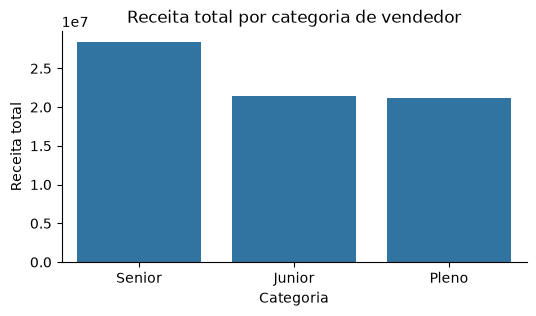

In [57]:
plt.figure(figsize=(6, 3))

sns.barplot(data=df_final, x='classificacao', y='receita_total', estimator='sum', errorbar=None)

plt.title('Receita total por categoria de vendedor')
plt.xlabel('Categoria')
plt.ylabel('Receita total')
sns.despine() 

plt.show()

Apesar de ser aleatório por opção (vide seções anteriores), os vendedores senior acabaram ficando com a liderança de receita total.

### B. Gráfico de linha

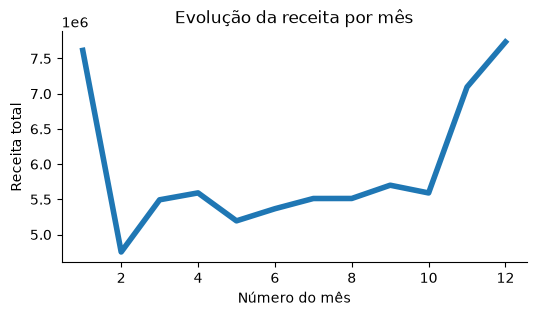

In [58]:
receita_mes = df_final.groupby('mes')['receita_total'].sum()

plt.figure(figsize=(6, 3))
sns.lineplot(x=receita_mes.index, y=receita_mes.values, linewidth=4)

plt.title('Evolução da receita por mês')
plt.xlabel('Número do mês')
plt.ylabel('Receita total')
sns.despine()

plt.show()

É perceptível o aumento da receita no começo e fim do ano. Com base nisso, pode-se supor que sejam as vendas impulsionadas pelas festas de fim de ano (Natal e ano novo). 

### C. Gráfico de dispersão

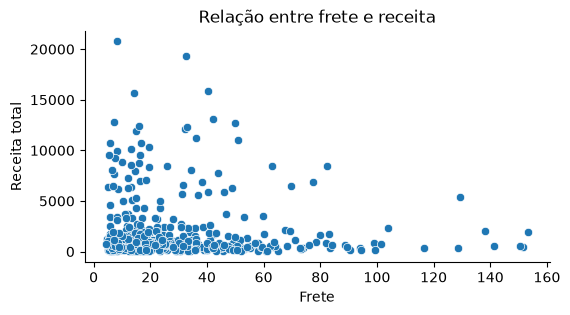

In [59]:
plt.figure(figsize=(6, 3))
sns.scatterplot(data=df.sample(500), x='frete', y='receita_total')

plt.title('Relação entre frete e receita')
plt.xlabel('Frete')
plt.ylabel('Receita total')
sns.despine()

plt.show()

Pode-se observar a ausência de frete grátis e que a maioria dos fretes parecem estar distribuidos entre 0 e 80. À vista, também não se observa correlação entre o frete e a receita.

### D. Mapa de calor

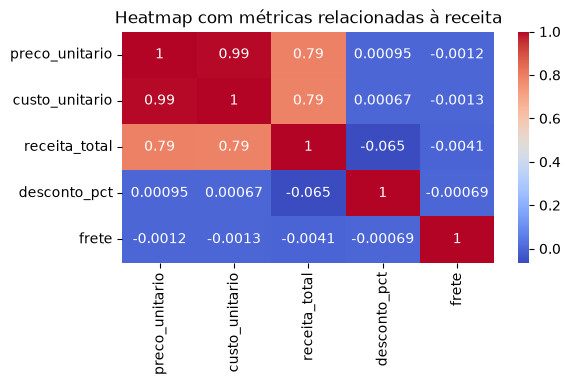

In [60]:
colunas = ['preco_unitario', 'custo_unitario', 'receita_total', 'desconto_pct', 'frete']

plt.figure(figsize=(6, 3))
sns.heatmap(df[colunas].corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap com métricas relacionadas à receita')
plt.show()

O heatmap não apresenta informações muito relevantes. O preço e o custo estão diretamente relacionados, o que era de se esperar, assim como a receita variar conforme o preço do produto.